# Lab 3: 3D reconstruction

In this lab you will learn how to perform triangulation, a common task in computer vision where 3D points are reconstructed using their 2D image projections and respective cameras. To estimate a single 3D point, two or more matching 2D image points and known camera matrices are needed. 

Specifically, you will use knowledge from the lectures on
- The pinhole camera model and the camera (projection) equation
- Reprojection errors
- Nonlinear least squares

**Observe:** You should not install any other packages than the ones given in the pre-amble. You are expected to yourself look up documentation of given functions from libraries, e.g. OpenCV. You are allowed to use any methods in the packages that you see fit to solve the problems. It is highly encouraged to look at the documentation and search for usage instructions online, before asking for help.

**Observe:** Write your answers to questions directly in the cells denoted with **Your answer**.

## Submission Requirements:
Your final lab submission should include:
1. Your executed **notebook file** (`.ipynb`) including an AI usage statement.
2. A **HTML printout** of the executed notebook with all outputs visible. 

## AI Usage Statement
Please detail your use of AI in this cell.

First, we'll import a set of python packages you'll need for this lab.

In [1]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.linalg import expm
from typing import Tuple, List, Optional
import pandas as pd
from PIL import Image

## Task 1: Triangulation using RANSAC
In this task you will reconstruct a 3D image of the Florence cathedral, using 2D image points and camera matrices.

This lab is centred on the camera equation
$$ \lambda \tilde{\mathbf{x}} = P\tilde{\mathbf{X}},$$
where $ \tilde{\mathbf x} $ is a 3-vector with the homogenous coordinates of a point in the image
$$ \tilde{\mathbf{x}} = \begin{bmatrix}
x \\
y \\
1
\end{bmatrix}  $$
and $ \tilde{\mathbf X} $ is a 4-vector containing the homogenous coordinates of the corresponding 3D point
$$ \tilde{\mathbf{X}} = \begin{bmatrix}
X \\
Y \\
Z\\
1
\end{bmatrix}. $$
The function `triangulation_test_case` is provided for creating a simple test case where you know the correct answer (`X_true`). Gaussian noise of standard deviation `sigma` is added to the image points. Use this example to evaluate your minimal solver.


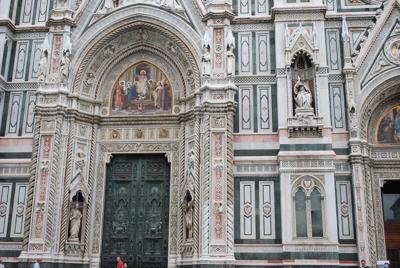

In [2]:
image = Image.open("./data/duomo.jpg")
image.thumbnail((400, 400))
image

In [3]:
def small_rotation(max_angle: float) -> np.ndarray:
    """
    Generates a small random 3D rotation matrix.

    Args:
    - max_angle (float): Maximum rotation angle in radians

    Returns
    - R (np.ndarray): 3x3 rotation matrix representing a random rotation
    """
    
    # Generate a random axis
    axis = np.random.randn(3)
    axis /= np.linalg.norm(axis)

    # Random angle scaled by max_angle
    angle = max_angle * np.random.rand()

    # Axis-angle vector
    s = axis * angle

    # Skew-symmetric matrix
    skew_s = np.array([
        [0, -s[2], s[1]],
        [s[2], 0, -s[0]],
        [-s[1], s[0], 0]
    ])

    # Rotation matrix
    R = expm(skew_s)

    return R

def triangulation_test_case(noise: float) -> Tuple[List[np.ndarray], np.ndarray, np.ndarray]:
    """
    Generates a synthetic triangulation problem with noisy 2D observations.

    Args:
    - noise (float): Standard deviation of the Gaussian noise added to the image points

    Returns:
    - Ps (List[np.ndarray]): List of two 3x4 projection matrices
    - xs (np.ndarray): 2x2 numpy array of noisy 2D image points (one column per camera)
    - X_true (np.ndarray): 3x1 numpy array representing the true 3D point
    """
    
    # Ground truth 3D point
    X_true = np.random.rand(3, 1)

    # Camera centers
    C1 = np.random.rand(3, 1) + np.array([[0], [0], [-4]])
    C2 = np.random.rand(3, 1) + np.array([[0], [0], [-4]])

    # Intrinsic matrix
    K = np.diag([2000, 2000, 1])

    # Projection matrices
    P1 = K @ small_rotation(0.1) @ np.hstack((np.eye(3), -C1))
    P2 = K @ small_rotation(0.1) @ np.hstack((np.eye(3), -C2))

    Ps = [P1, P2]

    # Project U_true into image coordinates
    x1 = P1 @ np.vstack((X_true, [[1]]))
    x2 = P2 @ np.vstack((X_true, [[1]]))

    # Normalize and add noise
    x1 = x1 / x1[2] + noise * np.random.randn(3, 1)
    x2 = x2 / x2[2] + noise * np.random.randn(3, 1)

    # Remove the third row (homogeneous coordinate)
    xs = np.hstack((x1[:2], x2[:2]))

    return Ps, xs, X_true

def compare_flattened_arrays(
        A_true: np.ndarray,
        A_est: np.ndarray,
        names: Optional[List[str]] = None
) -> None:
    """
    Compares the true and estimated flattened arrays
    
    Args:
    - A_true (np.ndarray): A true matrix to be printed.
    - A_est (np.ndarray): The estimated matrix printed.
    - names (List[str]): List of names for each element in the arrays.

    Returns:
    None
    
    """
    A_true_flattened = A_true.flatten()
    A_est_flattened = A_est.flatten()
    n_elements = A_true_flattened.size

    assert len(A_est_flattened) == n_elements, "True and estimated arrays must have the same number of elements."

    df_for_printing = pd.DataFrame(columns=names if names else [f"{i}" for i in range(n_elements)],
                                    data=[A_true_flattened, A_est_flattened],
                                    index=["True", "Estimated"])
    display(df_for_printing)

In [4]:
sigma = 0.2
Ps, xs, X_true = triangulation_test_case(sigma)
print(f"\nX_true:\n {X_true}")


X_true:
 [[0.66477121]
 [0.70256123]
 [0.15741569]]


### Task 1.1
Make a minimal solver for the triangulation problem, that is, a function `minimal_triangulation` that takes two camera matrices, `Ps`, and two image points, `xs`, and triangulates a 3D point. The image points are in a 2 x 2 numpy array whereas the camera matrices are in a list containing two numpy arrays. 

In [5]:
def minimal_triangulation(Ps, xs):
    """
    Makes a minimal solver for camera matrices and 2D observations to find the 3D point.

    Args:
    - Ps (List[np.ndarray]): list of two (3x4) camera projection matrices as numpy arrays
    - xs (np.ndarray): (2x2) numpy array of image coordinates, where each column corresponds to a point in one image

    Returns:
    - X (np.ndarray): 3D point (3,) as a numpy array
    """
    # YOUR CODE HERE
    A = []
    for i, P in enumerate(Ps):
        x, y = xs[0, i], xs[1, i]
        A.append(y * P[2, :] - P[1, :])
        A.append(P[0, :] - x * P[2, :])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    X_hom = Vt[-1, :]
    X = X_hom[:3] / X_hom[3]
    return X

In [6]:
X = minimal_triangulation(Ps, xs)

compare_flattened_arrays(X_true, X, names=["X", "Y", "Z"])

,X,Y,Z
True,0.664771,0.702561,0.157416
Estimated,0.664625,0.701901,0.153589


### Task 1.2
Recall that $\lambda$ is the *depth*. Points with negative depth would lie behind the camera, so negative depths indicate that something is wrong. Make a function `check_depths` that takes *N* camera matrices, `Ps`, and a 3D point, `X`, and checks the depth of `X` in each of the cameras. The output should be an array of boolean integer values of length *N* that indicates which depths were positive (1) or not (0). 

In [7]:
def check_depths(Ps, X):
    """
    Checks the depths of a 3D point from the perspective of multiple cameras.

    Args:
    - Ps (List[np.ndarray]): list of N camera matrices (each 3x4)
    - X (np.ndarray): 3D point as a NumPy array of shape (3,)

    Returns:
    - depths (np.ndarray): NumPy array of 0s and 1s indicating positive depth for each camera, shape (N,)
    """
    # YOUR CODE HERE
    X_hom = np.append(X, 1)  
    depths = []
    for P in Ps:
        x_proj = P @ X_hom
        depths.append(1 if x_proj[2] > 0 else 0)
    return np.array(depths)

In [8]:
depths = check_depths(Ps, X)
print(f"\nDepths:\n {depths}")


Depths:
 [1 1]


### Task 1.3
Make a function `reprojection_errors` that takes *N* camera matrices, `Ps`, *N* image points, `xs`, and a 3D point, `X`, and computes a vector with the reprojection errors, that is, the lengths of the reprojection residuals. If a point has negative depth, set the reprojection error to Inf. 

In [9]:
def reprojection_errors(Ps: List[np.ndarray], xs: np.ndarray, X: np.ndarray) -> np.ndarray:
    """
    Computes the reprojection errors for a 3D point X given camera matrices and observed image points.

    Args:
    - Ps (List[np.ndarray]): list of camera matrices (each 3x4 numpy array)
    - xs (np.ndarray): 2xN numpy array of image coordinates (each column is a point)
    - X (np.ndarray): 3D point as a numpy array of shape (3,)
    
    Returns: 
    - errors (np.ndarray): array of reprojection errors (N,)
    """
    # YOUR CODE HERE
    errors = []
    X_hom = np.append(X, 1.0)
    for i in range(len(Ps)):
        P = Ps[i]
        x_proj_hom = P @ X_hom
        x_proj = x_proj_hom[:2] / x_proj_hom[2]
        x_meas = xs[:, i]
        errors.append(x_proj[0] - x_meas[0])
        errors.append(x_proj[1] - x_meas[1])
    return np.array(errors)

In [10]:
errors = reprojection_errors(Ps, xs, X)
print(f"\nReprojection Errors:\n {errors}")


Reprojection Errors:
 [ 0.07339259  0.08102852 -0.06065841 -0.07762224]


### Task 1.4
Make a function `ransac_triangulation` that implements triangulation using RANSAC. Use the number of outliers as loss function. A measurement is deemed as an outlier if the depth is negative or if the reprojection error is larger than `threshold`.  

In [11]:
def ransac_triangulation(Ps, xs, threshold):
    """
    Performs RANSAC-based triangulation to find the best 3D point estimate given multiple camera observations.

    Args:
    - Ps (List[np.ndarray]): list of camera matrices (each 3x4)
    - xs (np.ndarray): 2xN numpy array of image coordinates
    - threshold (float): reprojection error threshold for inlier selection

    Returns:
    - X (np.ndarray): best estimated 3D point (3,)
    - nbr_inliers (int): number of inliers for best estimate
    """
    # YOUR CODE HERE
    N = len(Ps)
    best_X = None
    best_inliers = -1
    iterations = 1000
    
    if N < 2:
        return None, 0
    
    for _ in range(iterations):
        idx = np.random.choice(N, 2, replace=False)
        
        A = []
        for i in idx:
            P = Ps[i]
            x_meas, y_meas = xs[0, i], xs[1, i]
            
            A.append(x_meas * P[2, :] - P[0, :])
            A.append(y_meas * P[2, :] - P[1, :])
            
        A = np.array(A)
        
        _, _, Vh = np.linalg.svd(A)
        X_hom = Vh[-1, :]
        
        if X_hom[3] == 0:
            continue
            
        X_est = X_hom[:3] / X_hom[3]
        X_est_hom = np.append(X_est, 1.0)
        
        inliers = 0
        for i in range(N):
            P = Ps[i]
            x_meas = xs[:, i]
            
            uvw = P @ X_est_hom
            depth = uvw[2]
            
            if depth <= 0:
                continue
                
            proj = uvw[:2] / depth
            
            error = np.linalg.norm(proj - x_meas)
            if error <= threshold:
                inliers += 1

        if inliers > best_inliers:
            best_inliers = inliers
            best_X = X_est
        
        if best_inliers == N:
            break
            
    return best_X, best_inliers

In [12]:
threshold =  2
[X, nbr_inliers] = ransac_triangulation(Ps, xs, threshold) 

compare_flattened_arrays(X_true, X, names=["X", "Y", "Z"])
print(f"\nNumber of inliers: {nbr_inliers}")

,X,Y,Z
True,0.664771,0.702561,0.157416
Estimated,0.664625,0.701901,0.153589



Number of inliers: 2


### Task 1.5
In `sequence.mat` you find a struct array `triangulation_examples` with triangulation examples. Each example (corresponding to a 3D point) has a list of camera matrices `Ps` and a 2 x *N*-array `xs` with image points. Run `ransac_triangulation` for all (or at least 5000) of the examples from `sequence.mat`. It will take some time to triangulate all 32183 examples so start with the first 1000 or so. We used a RANSAC threshold of 5 pixels. Store all triangulated points with at least two inliers and plot them using `scatter`. There will always be a few outliers among the estimated 3D points that make it harder to view the plot. You can use the provided function `clean_for_plot` to clean it up a bit. 


In [13]:
def clean_for_plot(Xs: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Removes the 1% most extreme values in each dimension.
    
    Args:
    - Xs (np.ndarray): 3xN numpy array with the points to clean

    Returns:
    - Us_clean (np.ndarray): Cleaned points, 3xM array with M < N
    - removed_indices (np.ndarray): Indices of the removed points, boolean array
    """
    # Compute the 1st and 99th percentiles along each dimension (row)
    minvals = np.percentile(Xs, 1, axis=1)
    maxvals = np.percentile(Xs, 99, axis=1)

    # Find indices of points outside the defined percentiles
    removed_indices = (Xs[0, :] > maxvals[0]) | (Xs[0, :] < minvals[0])
    for kk in range(1, 3):
        removed_indices |= (Xs[kk, :] > maxvals[kk]) | (Xs[kk, :] < minvals[kk])

    # Filter the points to keep only the ones not removed
    Xs_clean = Xs[:, ~removed_indices]

    return Xs_clean, removed_indices


def equal_aspect_ratio(ax: Axes3D) -> None:
    """
    Sets equal aspect ratio in a 3D matplotlib plot by adjusting axis limits.

    Args:
    - ax (Axes3D): A matplotlib 3D axis (Axes3D)

    Returns:
    - None (modifies the axis limits in-place)
    """

    # Note: ax.set_box_aspect([1, 1, 1]) does not actually adjust axis *limits*,
    # so the plot may still look distorted if x/y/z ranges differ.
    # This function ensures a cubic data volume by explicitly setting equal limits.
    
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    z_range = z_limits[1] - z_limits[0]
    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim([x_middle - max_range/2, x_middle + max_range/2])
    ax.set_ylim([y_middle - max_range/2, y_middle + max_range/2])
    ax.set_zlim([z_middle - max_range/2, z_middle + max_range/2])

**Observe**: Since the RANSAC triangulation has a random element to it, the result may need to be run a few times to get a nice result, since all outliers may not necessarily be removed.

In [ ]:
# Load data
data = scipy.io.loadmat('data/sequence.mat')

n_examples = 5000
triangulation_examples = data['triangulation_examples'][0][:n_examples]  # MATLAB structs in a 1D object array

threshold = 5
Xs = np.zeros((3, n_examples)) # Preallocate array for triangulated points

# Triangulate each example and store results in Xs
for i in range(n_examples):
    example = triangulation_examples[i]
    
    # Access fields inside the struct
    Ps = [example['Ps'][0, j] for j in range(example['Ps'].shape[1])]
    xs = example['xs']

    # YOUR CODE HERE
    X_est, nbr_inliers = ransac_triangulation(Ps, xs, threshold)

    if X_est is not None and nbr_inliers >= 2:
        Xs[:, i] = X_est
    else:
        Xs[:, i] = np.nan

# Plot triangulated points
Xc, removed_indices = clean_for_plot(Xs) 

# Create a 3D scatter plot
f, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='3d'))
ax.scatter(Xc[0, :], Xc[1, :], Xc[2, :], marker='.', alpha=0.8)
# Set axis equal for better scaling
equal_aspect_ratio(ax)
plt.show()

NotImplementedError: 

## Task 2: Least squares triangulation 
In this part of the lab you will solve the triangulation problem through least squares, and uncover a secret message encoded in the 3D points... The following pipeline is recommended: 
- Use RANSAC to obtain a rough estimate of the parameters (*X*). 
- Remove all measurements which are outliers with respect to these parameters. 
- Estimate the least squares parameters using the remaining measurements.

Note that in this case a *measurement* is a pair consisting of an image point $\mathbf{\tilde{x}}_i$ and a camera matrix $P_i$. Don’t forget that points with negative depths should be outliers. 

### Task 2.1
Consider a camera matrix
$$ P_i = \begin{bmatrix}
\leftarrow \mathbf{a}_i^T \rightarrow \\
\leftarrow \mathbf{b}_i^T \rightarrow \\
\leftarrow \mathbf{c}_i^T \rightarrow
\end{bmatrix} , $$
a 3D point *X* and an image point $\mathbf{\tilde{x}}_i$. Write the exact formula for the reprojection error $r_i(\mathbf{\tilde{X}})$ below.

**Your answer:**


As you can see, the residuals are no longer linear, so computing a least squares solution will be significantly harder than in the previous lab. In fact, we cannot be sure to find the least squares solution. What we can do is to use local optimization to reduce the sum of squared residuals. We start at the solution produced by RANSAC and use a few Gauss-Newton iterations.

### Task 2.2
Make a function `compute_residuals` that takes a list `Ps` with *N* cameras, a 2 x *N* array `xs` of image points and a size 3 vector `X`, and computes a 2*N* vector with all the reprojection residuals stacked into a single vector/array. A reprojection residual is a 2D vector corresponding to the difference between the original measurement and the projected point. The stacked vector is the $\bar{r}$ from *Lecture Notes in Image Analysis* (p. 99).

In [ ]:
def compute_residuals(Ps: List[np.ndarray], xs: np.ndarray, X: np.ndarray) -> np.ndarray:
    """
    Computes the reprojection residuals for a given 3D point X across multiple cameras.

    Args:
    - Ps (List[np.ndarray]): list of camera matrices (each 3x4 numpy array)
    - xs (np.ndarray): 2xN numpy array of observed image coordinates
    - X (np.ndarray): 3D point as a numpy array of shape (3,)
    
    Returns:
    - all_residuals (np.ndarray): (2N,) numpy array of residuals (x and y reprojection errors)
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Usage example for one 3D point
index_point = 0
example = triangulation_examples[index_point]
Ps_example = [example['Ps'][0, j] for j in range(example['Ps'].shape[1])] # Access fields inside the struct
xs_example = example['xs']
X_example =  Xs[:,index_point]

all_residuals = compute_residuals(Ps_example, xs_example, X_example)
print(f"\nReprojection Residuals for point {index_point}:\n {all_residuals}")

### Task 2.3
Find formulas for the partial derivatives in the Jacobian of $\bar{r}$. The Jacobian should be a 2*N* x 3- matrix. (Hint: you can start by finding the formula to the Jacobian of the i-th residual, which is a 2x3 matrix.) Please write down the exact formula and give a brief description about each variable that appears in the formula.   

**Your answer:**


### Task 2.4: 
Make a function `compute_jacobian`, that computes the Jacobian given a 3 x 1- vector `X` and a list of arrays of camera matrices `Ps`. 

In [ ]:
def compute_jacobian(Ps: List[np.ndarray], X: np.ndarray) -> np.ndarray:
    """
    Computes the Jacobian matrix of reprojection errors w.r.t. the 3D point X.

    Args:
    - Ps (List[np.ndarray]): list of camera matrices (each 3x4 numpy array)
    - X (np.ndarray): 3D point as a numpy array of shape (3,)

    Returns:
    - jacobian (np.ndarray): (2N x 3) numpy array, Jacobian matrix of reprojection errors w.r.t. X
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Usage example
all_residuals = compute_jacobian(Ps_example, X_example)

### Task 2.5
Use the functions `compute_residuals` and `compute_jacobian` to make a function `refine_triangulation` that uses an approximate 3D point `Xhat` as a starting point for Gauss-Newton’s method. Use five Gauss-Newton iterations.

In [ ]:
def refine_triangulation(Ps: List[np.ndarray], xs: np.ndarray, Xhat: np.ndarray, iterations: int = 5):
    """
    Refines a 3D point estimate using Gauss-Newton optimization.

    Args:
    - Ps (List[np.ndarray]): list of camera matrices (3x4 numpy arrays)
    - xs (np.ndarray): 2xN numpy array of 2D image points
    - Xhat (np.ndarray): initial estimate of the 3D point (3,)
    - iterations (int): number of Gauss-Newton iterations (default: 5)

    Returns:
    - X (np.ndarray): refined 3D point (3,)
    - residual_norms (np.ndarray): norm of residuals at each iteration (for monitoring convergence)
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Usage example
Xref, residual_norms = refine_triangulation(Ps_example, xs_example, X_example)
print(f"\nRefined 3D point:\n {Xref}")

f, ax = plt.subplots()
ax.plot(residual_norms, marker='o')
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual Norm')
plt.show()

### Task 2.6
Try your `refine_triangulation` on the data in `gauss_newton.mat`. First we will plot the points given in `Xhat`, then refine each point using your function and plot the results using `scatter`. You should see an improvement. 

In [ ]:
# Load data
data = scipy.io.loadmat('data/gauss_newton.mat')
Xhat = data['Uhat']        # 3xN
x = data['u']              # 2xN
x_tilde = data['u_tilde']  # 2xN
P = data['P']              # 3x4
P_tilde = data['P_tilde']  # 3x4

# Plot initial points
f, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': '3d'})
ax.scatter(Xhat[0], Xhat[1], Xhat[2], c='blue', marker='.')
ax.set_title('Initial 3D Points (Xhat)')
ax.view_init(elev=0, azim=-90) # Set view angle

# Set axis equal for better scaling
equal_aspect_ratio(ax)

plt.tight_layout()
plt.show()

# Refine each point
N = Xhat.shape[1]
Xref = np.zeros((3, N))
Ps = [P, P_tilde]

residual_norms = np.zeros((N, 5))
for i in range(N):
    image_points = np.column_stack((x[:, i], x_tilde[:, i]))  # 2x2
    xref, rn = refine_triangulation(Ps, image_points, Xhat[:, i])
    Xref[:, i] = xref
    residual_norms[i, :] = rn

# Plot refined points
f, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': '3d'})
ax.scatter(Xref[0], Xref[1], Xref[2], c='blue', marker='.')
ax.set_title('Refined 3D Points')
ax.view_init(elev=0, azim=-90) # Set view angle

# Set axis equal for better scaling
equal_aspect_ratio(ax)

plt.tight_layout()
plt.show()

### Task 2.7
Create a function `camera_centers_and_viewing_directions`, compute the camera positions for the data in `gauss_newton.mat` and plot them together with the estimated 3D points. Both the camera centers and viewing directions should be computed. 

_Hint_: The camera center and viewing direction in the camera coordinate system are known. Your task is to compute them in the global coordinate system.

In [ ]:
def camera_centers_and_viewing_directions(Ps: List[np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Computes the camera centers and viewing directions from a list of projection matrices.

    Args:
    - Ps (List[np.ndarray]): list of camera projection matrices (each 3x4)

    Returns:
    - centers (np.ndarray): 4xN array of camera centers, where N is the number of cameras
    - viewing_directions (np.ndarray): 3xN array of viewing directions, where N is the number of cameras
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Create 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot refined 3D points (Uref)
ax.scatter(Xref[0], Xref[1], Xref[2], c='blue', marker='.', alpha=0.3)

# Compute camera positions
centers, viewing_directions = camera_centers_and_viewing_directions(Ps)
print(centers.shape, viewing_directions.shape)

 # Plot camera centers and viewing directions
ax.quiver(centers[0, :], centers[1, :], centers[2, :],
        viewing_directions[0, :], viewing_directions[1, :], viewing_directions[2, :],
        color='r', linewidth=1.5)



ax.view_init(elev=10, azim=-85) # These angles should work as is

# Set axis equal for better scaling
equal_aspect_ratio(ax)

# Set the limits of the axes for better visualization
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_zlim(-1, 4)

# Show plot
plt.show()
